In [3]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 20.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.0/461.0 kB 13.0 MB/s eta 0:00:00


In [ ]:
#imports & data loading

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from lightgbm import LGBMClassifier
import joblib

train_identity = pd.read_csv('INFO442Data/train_identity.csv')
train_transaction = pd.read_csv('INFO442Data/train_transaction.csv')

In [ ]:
#merge transaction and identity datasets

In [3]:
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
print(f'Train dataset has {train.shape[0]} rows and {train.shape[1]} columns.')

print("Dataset shape:", train.shape)

Train dataset has 590540 rows and 434 columns.
Dataset shape: (590540, 434)


split data

In [5]:
X = train.drop(
    columns=[
        "isFraud",
        "TransactionID"
    ]
)

y = train["isFraud"]


X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Train:", X_train.shape)
print("Valid:", X_valid.shape)



Train: (472432, 432)
Valid: (118108, 432)


In [ ]:
#feature engineering

In [7]:
def add_row_features(df):

    df = df.copy()

    # Transaction amount
    df["TransactionAmt_log"] = np.log1p(
        df["TransactionAmt"]
    )

    df["TransactionAmt_decimal"] = (
        df["TransactionAmt"] % 1
    )


    # Time features
    df["Transaction_hour"] = (
        (df["TransactionDT"] // 3600) % 24
    )

    df["Transaction_day"] = (
        df["TransactionDT"] // (3600 * 24)
    )


    # Missing values
    df["missing_count"] = (
        df.isnull().sum(axis=1)
    )


    # Identity missingness
    identity_cols = [
        c for c in df.columns
        if c.startswith("id_")
    ]

    if len(identity_cols) > 0:
        df["identity_missing"] = (
            df[identity_cols]
            .isnull()
            .sum(axis=1)
        )


    # Email match
    if (
        "P_emaildomain" in df.columns
        and "R_emaildomain" in df.columns
    ):
        df["email_match"] = (
            df["P_emaildomain"]
            ==
            df["R_emaildomain"]
        ).astype("int8")


    return df


X_train = add_row_features(X_train)
X_valid = add_row_features(X_valid)

In [ ]:
#(train) frequency encoding

In [9]:
freq_cols = [
    "card1",
    "card2",
    "card3",
    "card5",
    "addr1",
    "addr2",
    "P_emaildomain",
    "R_emaildomain",
    "DeviceInfo"
]


def add_frequency_features(
    train_df,
    valid_df,
    columns
):

    train_df = train_df.copy()
    valid_df = valid_df.copy()

    for col in columns:

        if col in train_df.columns:

            freq = train_df[col].value_counts(
                dropna=False
            )

            train_df[col + "_freq"] = (
                train_df[col].map(freq)
            )

            valid_df[col + "_freq"] = (
                valid_df[col].map(freq)
                .fillna(0)
            )

    return train_df, valid_df



X_train, X_valid = add_frequency_features(
    X_train,
    X_valid,
    freq_cols
)



In [ ]:
#convert categorical columns

In [11]:
cat_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()


for col in cat_cols:

    X_train[col] = (
        X_train[col]
        .astype("category")
    )

    X_valid[col] = (
        X_valid[col]
        .astype("category")
    )


In [ ]:
#create + train lgbm model

In [13]:
model = LGBMClassifier(

    objective="binary",

    n_estimators=2000,
    learning_rate=0.02,

    num_leaves=64,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=0.1,

    class_weight="balanced",

    random_state=42,
    n_jobs=-1
)

In [15]:
model.fit(

    X_train,
    y_train,

    categorical_feature=cat_cols,

    eval_set=[
        (X_valid, y_valid)
    ],

    eval_metric="auc"
)

/opt/anaconda3/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.298017 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41317
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 447
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.02, n_estimators=2000, n_jobs=-1, num_leaves=64,
               objective='binary', random_state=42, reg_alpha=0.1,
               reg_lambda=0.1, subsample=0.8)

In [ ]:
#evaluate model 

In [17]:
valid_pred = model.predict_proba(
    X_valid
)[:, 1]


auc = roc_auc_score(
    y_valid,
    valid_pred
)


print(
    "Validation AUC:",
    auc
)


Validation AUC: 0.968707420577702


In [ ]:
#calculate feature importance

In [19]:
importance = pd.DataFrame({

    "feature": X_train.columns,

    "importance": model.feature_importances_

})


importance = importance.sort_values(
    "importance",
    ascending=False
)


print(
    importance.head(30)
)

                    feature  importance
439              card1_freq        5331
3                     card1        4778
1            TransactionAmt        4408
9                     addr1        4367
4                     card2        4315
13            P_emaildomain        3949
0             TransactionDT        3899
440              card2_freq        3595
422                   id_31        3472
443              addr1_freq        3420
431              DeviceInfo        2977
43                      D15        2734
11                    dist1        2509
27                      C13        2413
30                       D2        2113
435         Transaction_day        2069
32                       D4        2031
38                      D10        1986
433  TransactionAmt_decimal        1805
29                       D1        1665
421                   id_30        1647
39                      D11        1614
7                     card5        1553
434        Transaction_hour        1433


In [ ]:
#EDA plots

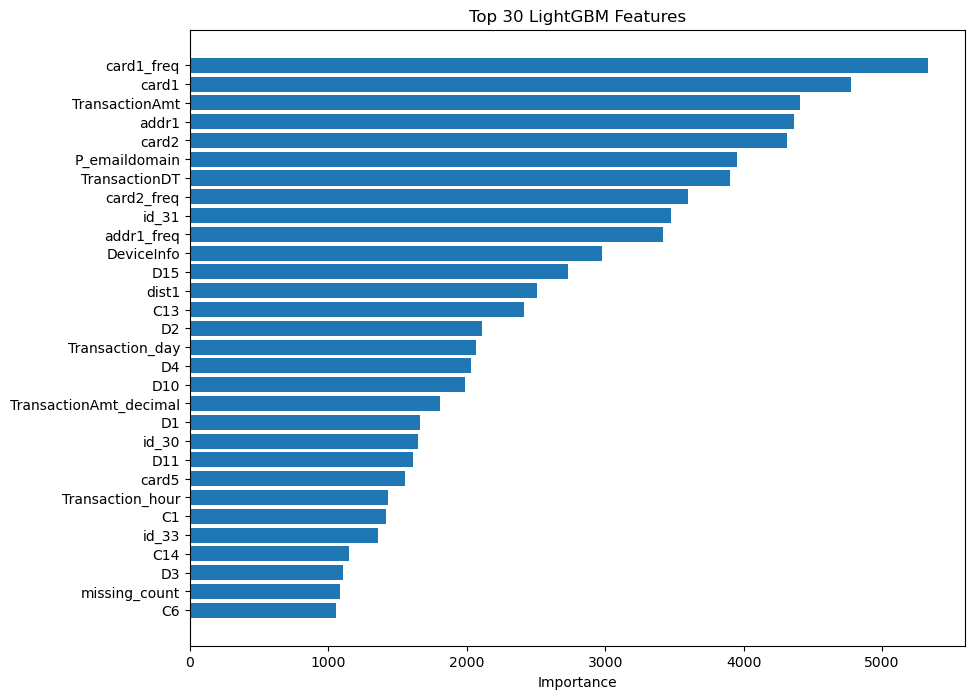

In [21]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
).head(30)


plt.figure(figsize=(10,8))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 30 LightGBM Features"
)

plt.xlabel(
    "Importance"
)

plt.show()

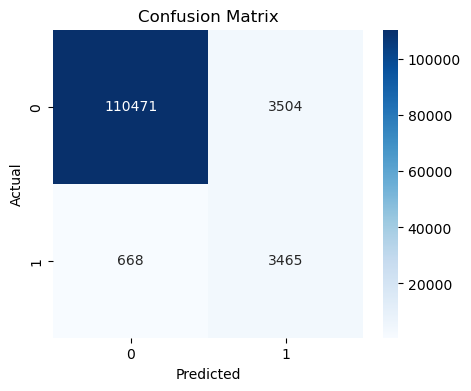

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

valid_class = (
    valid_pred > 0.5
).astype(int)


cm = confusion_matrix(
    y_valid,
    valid_class
)


plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

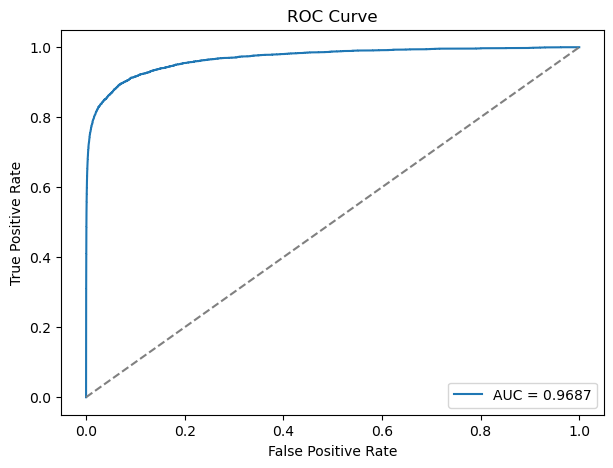

In [29]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt


fpr, tpr, thresholds = roc_curve(
    y_valid,
    valid_pred
)


plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
#save lgbm models

In [25]:
joblib.dump(
    model,
    "ieee_cis_lgbm.pkl"
)

print("Model saved")

Model saved
